# Разработка кастомной поисковой системы

> [Основной источник информации](https://developers.google.com/search/docs/appearance/ranking-systems-guide)

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from collections import Counter, defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Эволюция поисковых систем

**Archie** — первая поисковая система; инструмент индексирования FTP-архивов.

> **File Transfer Protocol** — распределенные хранилища (депозиторий) файлов; один из самых старых протоколов передачи файлов, который появился в 1971 году

**Годы жизни**: 1990-е.

**Причина смерти**: вытеснен Jughead и Veronica для протокола Gopher

> **Gopher** — протокол распределенного поиска и передачи документов; предлагает иерархическую структуру меню вместо гипертекста HTTP; использует 70-й TCP-порт, отличается высокой скоростью и сегодня поддерживается узким сообществом энтузиастов как "легкая" альтернатива вебу.

**TCP-порт** — это 16-битное число (от 0 до 65535), используемое протоколом управления передачей (TCP) для идентификации конкретного процесса или приложения на хосте. Он обеспечивает маршрутизацию данных между клиентом и сервером: порт назначения указывает получателя (например, 80 для HTTP), а порт источника — отправителя.

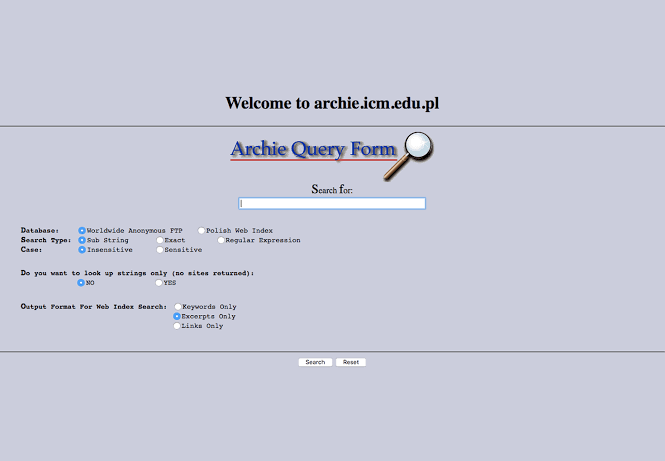

*Обратите внимание, что ни Archie, ни Gopher-based поисковики ни работали с вебом*

Вебом мы называем сервис, построенный на HTTP-протоколе. Он отличается от других протоколов (напр., для email или упомянутый FTP для хранения и передачи файлов) тем, что обрабатывает связанные ссылками документами в W3

| Год | Поисковая система | Инновация |
|-----|------------------|-----------|
| 1990 | Archie | Первая поисковая система для FTP-архивов |
| 1993 | Wandex | Первый веб-поисковик |
| 1994 | WebCrawler | Первый полнотекстовый поиск |
| 1994 | Lycos | Массовая индексация (54k документов) |
| 1995 | AltaVista | Передовые текстовые алгоритмы |
| 1998 | **Google** | **PageRank - новый способ ранжирования** |

Ранние поисковики (AltaVista, Excite) использовали **term-frequency based ranking**:
- Подсчет вхождений ключевых слов
- Игнорирование качества и авторитетности страниц
- Легко поддавались манипуляции (keyword stuffing)

In [ ]:
# Демонстрация проблемы: простая TF-based релевантность
def simple_tf_ranking(query, documents):
    """Примитивное ранжирование по частоте слов"""
    scores = {}
    query_words = set(query.lower().split())

    for doc_id, doc_text in documents.items():
        doc_words = doc_text.lower().split()
        # Простой подсчет совпадений
        score = sum(1 for word in query_words if word in doc_words)
        scores[doc_id] = score

    return sorted(scores.items(), key=lambda x: x[1], reverse=True)

# Пример
docs = {
    "doc1": "buy cheap watches chinese high quality very good quality 2021 2023 2026",
    "doc2": "watch repair expert guide quality watches",
    "doc3": "best luxury watches reviews 2026"
}

query = "quality watches 2026"
print("TF-based ranking:", simple_tf_ranking(query, docs))
# ('doc1', 1) может оказаться выше из-за спама

TF-based ranking: [('doc1', 3), ('doc2', 2), ('doc3', 2)]


## 2. PageRank

PageRank моделирует интернет как **направленный граф**, где:
- **Вершины (nodes)** — веб-страницы
- **Ребра (edges)** — гиперссылки между страницами

Важность страницы определяется количеством и качеством ссылок на нее

> *"Ссылка с сайта А на сайт В — это голос А в пользу В"* — Ларри Пейдж

**Классическая формула PageRank:**

$$PR(p_i) = \frac{1-d}{N} + d \sum_{p_j \in M(p_i)} \frac{PR(p_j)}{L(p_j)}$$

Где:
- $PR(p_i)$ — PageRank страницы $p_i$
- $d$ — **damping factor** (обычно 0.85) — вероятность продолжения "случайного серфинга"
- $N$ — общее количество страниц
- $M(p_i)$ — множество страниц, ссылающихся на $p_i$
- $L(p_j)$ — количество исходящих ссылок со страницы $p_j$


Собственный вектор матрицы $A$ — это ненулевой вектор $v$, для которого существует число $\lambda$ (собственное значение) такое, что $Av = \lambda v$

В модели PageRank матрица $A$ описывает переходы по ссылкам: каждый столбец — это текущая страница, каждая строка — следующая страница, а элементы — вероятности перехода (равные $1/\text{число ссылок}$)

Нам нужно распределение, которое не меняется после перехода: $A \cdot \mathbf{PR} = \mathbf{PR}$. Это уравнение на собственный вектор с $\lambda = 1$. Без него (или если таких векторов несколько) ранжирование неоднозначно. Собственный вектор даёт единственный фиксированный вектор

Собственный вектор с $\lambda \approx 1$ называют стационарным распределением. Если начать с такого вектора, то после любого числа шагов (переходов по графу) распределение вероятностей не меняется

Геометрически это устойчивое направление в графе страниц: важные страницы (с высоким PageRank) притягивают трафик независимо от начальной точки, действуя как аттрактор в многомерном пространстве

Аттрактор делает итоговый рейтинг независимым от стартовой точки и от конкретного пути пользователя к странице. С какого бы сайта ни начинал пользователь, после многих переходов распределение вероятностей будет одним и тем же

В реальном алгоритме Google добавляют телепортацию (вероятность случайного скачка — 0.15), чтобы собственное значение $\lambda = 1$ стало строгим, и решают систему уравнений:

$$
\mathbf{PR} = \left[ (1-d)\mathbf{1} + d \mathbf{M}^T \right] \mathbf{PR}
$$

- $\mathbf{PR}$ — вектор PageRank (искомое стационарное распределение)  
- $d = 0.85$ — вероятность перейти по ссылке (оставшиеся $0.15$ — телепортация)  
- $\mathbf{1}$ — вектор из единиц (равномерная телепортация на любую страницу)  
- $\mathbf{M}^T$ — транспонированная матрица переходов по ссылкам
- В скобках: взвешенная сумма телепортации $(1-d)\mathbf{1}$ и переходов по ссылкам $d\mathbf{M}^T$  

> Новый PageRank = взвешенная сумма равномерного распределения и распределения, полученного следованием по ссылкам. Решив его, получаем единственный устойчивый вектор, который и есть рейтинг Google.

## 3. Визуализация PageRank

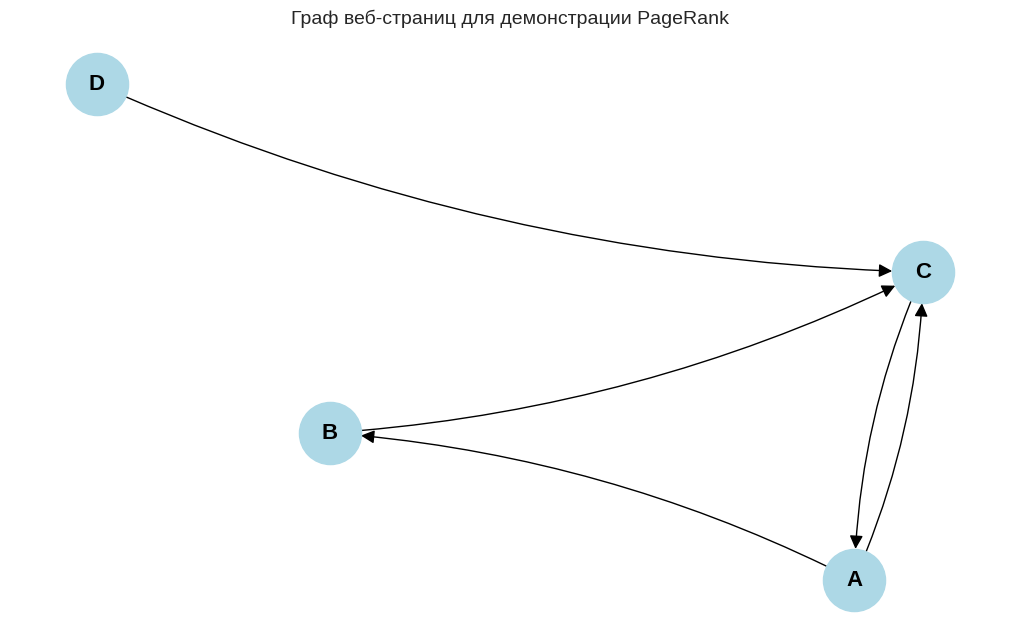

Сходимость достигнута на итерации 28

PageRank scores:
  C: 0.3941
  A: 0.3725
  B: 0.1958
  D: 0.0375


In [ ]:
def compute_pagerank(graph, damping=0.85, max_iter=100, tol=1e-6):
    """
    Вычисление PageRank для направленного графа

    Параметры:
    - graph: словарь {page: [outgoing_links]}
    - damping: коэффициент затухания (обычно 0.85)
    - max_iter: максимальное число итераций
    - tol: критерий сходимости

    Возвращает:
    - словарь {page: pagerank_score}
    """
    n = len(graph)
    pages = list(graph.keys())
    page_to_idx = {page: i for i, page in enumerate(pages)}

    # Построение матрицы переходов M
    M = np.zeros((n, n))
    for i, page in enumerate(pages):
        out_links = graph[page]
        if out_links:
            prob = 1.0 / len(out_links)
            for target in out_links:
                if target in page_to_idx:
                    j = page_to_idx[target]
                    M[j, i] += prob

    # Инициализация равномерным распределением
    pr = np.ones(n) / n

    # Итеративное вычисление
    for iteration in range(max_iter):
        new_pr = (1 - damping) / n + damping * M @ pr

        # Проверка сходимости
        if np.linalg.norm(new_pr - pr, 1) < tol:
            print(f"Сходимость достигнута на итерации {iteration + 1}")
            break

        pr = new_pr

    # Нормализация
    pr = pr / pr.sum()

    return {page: pr[i] for i, page in enumerate(pages)}

# Создадим пример графа веб-страниц
web_graph = {
    "A": ["B", "C"],
    "B": ["C"],
    "C": ["A"],
    "D": ["C"]
}

# Визуализация графа
G = nx.DiGraph(web_graph)
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=2000, font_size=16, font_weight='bold',
        arrows=True, arrowsize=20, connectionstyle='arc3,rad=0.1')
plt.title("Граф веб-страниц для демонстрации PageRank", fontsize=14)
plt.show()

# Вычисление PageRank
pr_scores = compute_pagerank(web_graph)
print("\nPageRank scores:")
for page, score in sorted(pr_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"  {page}: {score:.4f}")

Сходимость достигается, когда **изменение вектора PageRank между итерациями становится меньше заданного порога** `tol = 1e-6`

```python
if np.linalg.norm(new_pr - pr, 1) < tol:
```

Здесь используется **L1-норма** (сумма абсолютных разностей):

$$
\| \mathbf{PR}_{\text{new}} - \mathbf{PR}_{\text{old}} \|_1 = \sum_{i=1}^n |PR_{\text{new}, i} - PR_{\text{old}, i}|
$$

Если эта сумма меньше `1e-6`, алгоритм останавливается и сообщает: `"Сходимость достигнута на итерации X"`

**Геометрический смысл:**  
Вектор перестаёт заметно двигаться в пространстве распределений — попал в аттрактор (собственный вектор с λ=1)

Если увеличить `tol` (например, `1e-4`), сходимость наступит быстрее, но результат будет менее "откалиброванным". Если уменьшить (например, `1e-9`), итераций потребуется больше

## 4. Математическая интерпретация PageRank

**PageRank как решение системы линейных уравнений:**

$$ \begin{cases}
PR(A) = (1-d)/N + d \cdot [PR(C)/L(C)] \\
PR(B) = (1-d)/N + d \cdot [PR(A)/L(A)] \\
PR(C) = (1-d)/N + d \cdot [PR(A)/L(A) + PR(B)/L(B) + PR(D)/L(D)] \\
PR(D) = (1-d)/N
\end{cases} $$

**Свойства:**
- Сумма всех PageRank = 1 (вероятностное распределение)
- Страницы без входящих ссылок получают минимальный вес
- "Пауки" (страницы без исходящих ссылок) распределяют вес равномерно


В этом примере **A, B, C, D** — названия конкретных страниц из графа, который был задан выше в коде:

```python
web_graph = {
    "A": ["B", "C"],   # A ссылается на B и C
    "B": ["C"],        # B ссылается на C
    "C": ["A"],        # C ссылается на A
    "D": ["C"]         # D ссылается на C
}
```

**Расшифровка обозначений в системе уравнений:**

- $PR(A)$ — PageRank страницы A
- $L(A)$ — количество **исходящих** ссылок со страницы A (в примере: \(L(A)=2\), так как A ссылается на B и C)
- $N = 4$ — общее количество страниц
- $d = 0.85$ — коэффициент затухания (damping factor)

**Страница A** получает вес только от C, потому что:
   - B не ссылается на A
   - C ссылается на A

**Страница B** получает вес только от A

**Страница C** получает вес от A, B и D

**Страница D** — висячая (нет входящих ссылок), поэтому только телепортация

## 5. Современные факторы ранжирования Google
```python
# Структурированное представление факторов ранжирования
ranking_factors = {
    "Content-related (30%)": [
        "Keyword relevance and density",
        "Content freshness (Query Deserves Freshness)",
        "Content comprehensiveness",
        "Structured data markup",
        "Original content detection"
    ],
    "Link-related (25%)": [
        "PageRank and link authority",
        "Anchor text relevance",
        "Link quality (not quantity)",
        "Internal linking structure",
        "Link growth patterns"
    ],
    "User interaction (20%)": [
        "Click-through rate (CTR)",
        "Dwell time",
        "Bounce rate",
        "Pogo-sticking detection",
        "Repeat visits"
    ],
    "Technical (15%)": [
        "Mobile-friendliness",
        "Page speed (Core Web Vitals)",
        "HTTPS security",
        "Structured data",
        "Crawlability"
    ],
    "Query-specific (10%)": [
        "Query intent classification",
        "Local intent detection",
        "Freshness requirements",
        "User location",
        "Search history"
    ]
}
```


**RankBrain** — первая AI-система Google для ранжирования (2015):

$$ \text{Relevance}(q, d) = f_{\theta}( \text{emb}(q), \text{emb}(d) ) $$

Где $f_{\theta}$ — нейронная сеть, обучаемая на кликах пользователей

In [ ]:
# Симуляция Neural Matching
class NeuralMatching:
    """Упрощенная модель нейронного матчинга"""

    def __init__(self, embedding_dim=128):
        self.embedding_dim = embedding_dim
        # Симулируем предобученные эмбеддинги
        np.random.seed(42)
        self.word_embeddings = {}

    def get_embedding(self, text):
        """Получение эмбеддинга текста"""
        words = text.lower().split()
        if not words:
            return np.zeros(self.embedding_dim)

        # Симуляция эмбеддингов
        embeddings = []
        for word in words:
            if word not in self.word_embeddings:
                self.word_embeddings[word] = np.random.randn(self.embedding_dim)
            embeddings.append(self.word_embeddings[word])

        # Усреднение для получения векторного представления
        return np.mean(embeddings, axis=0)

    def compute_similarity(self, query, document):
        """Вычисление семантической близости"""
        q_emb = self.get_embedding(query)
        d_emb = self.get_embedding(document)

        # Косинусное сходство
        similarity = np.dot(q_emb, d_emb) / (np.linalg.norm(q_emb) * np.linalg.norm(d_emb) + 1e-8)
        return similarity

# Демонстрация
model = NeuralMatching()

queries = [
    "buy cheap laptop",
    "best budget notebook",
    "expensive gaming computer"
]

documents = [
    "Top 10 budget laptops under $500",
    "Gaming PC with RTX 4090 for sale",
    "How to fix laptop screen"
]

print("Semantic matching scores (Neural Matching simulation):\n")
for query in queries:
    print(f"\nQuery: '{query}'")
    for doc in documents:
        score = model.compute_similarity(query, doc)
        print(f"  vs '{doc[:40]}...': {score:.3f}")

Semantic matching scores (Neural Matching simulation):


Query: 'buy cheap laptop'
  vs 'Top 10 budget laptops under $500...': -0.108
  vs 'Gaming PC with RTX 4090 for sale...': 0.096
  vs 'How to fix laptop screen...': 0.114

Query: 'best budget notebook'
  vs 'Top 10 budget laptops under $500...': 0.151
  vs 'Gaming PC with RTX 4090 for sale...': 0.043
  vs 'How to fix laptop screen...': 0.110

Query: 'expensive gaming computer'
  vs 'Top 10 budget laptops under $500...': 0.082
  vs 'Gaming PC with RTX 4090 for sale...': 0.331
  vs 'How to fix laptop screen...': -0.002


## 6. Применение BERT

In [ ]:
from transformers import BertTokenizer, BertModel
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

tokenizer = BertTokenizer.from_pretrained("google-bert/bert-base-uncased")
model = BertModel.from_pretrained("google-bert/bert-base-uncased")
model.eval()

def get_bert_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
        attention_mask = inputs['attention_mask']
        token_embs = outputs.last_hidden_state
        mask_expanded = attention_mask.unsqueeze(-1).expand(token_embs.size())
        sum_embeddings = torch.sum(token_embs * mask_expanded, 1)
        sum_mask = torch.clamp(mask_expanded.sum(1), min=1e-9)
        embedding = sum_embeddings / sum_mask
    return embedding.numpy().flatten()

docs = [
    "mayo clinic official aspirin side effects bleeding stomach",
    "random personal blog my terrible aspirin experience",
    "nih government clinical trial aspirin bleeding risk 2024",
    "webmd aspirin dosage and safety information",
    "wikipedia aspirin medical uses and contraindications",
    "healthline aspirin side effects comprehensive guide",
    "medical journal the lancet aspirin bleeding study peer reviewed",
    "forum post aspirin caused my stomach bleed help",
    "fda official aspirin safety communication warning",
    "quora answer what are aspirin side effects"
]

query = "aspirin side effects"

query_emb = get_bert_embedding(query)
bert_scores = []
for doc in docs:
    doc_emb = get_bert_embedding(doc)
    score = cosine_similarity([query_emb], [doc_emb])[0][0]
    bert_scores.append(score)

pagerank_scores = []
for doc in docs:
    if 'gov' in doc or 'nih' in doc or 'fda' in doc:
        pagerank_scores.append(0.95)
    elif 'mayo' in doc or 'webmd' in doc or 'lancet' in doc:
        pagerank_scores.append(0.85)
    elif 'wikipedia' in doc or 'healthline' in doc:
        pagerank_scores.append(0.75)
    elif 'quora' in doc:
        pagerank_scores.append(0.40)
    else:
        pagerank_scores.append(0.15)

hybrid_scores = [0.6*b + 0.4*p for b, p in zip(bert_scores, pagerank_scores)]

print("RANKING: PAGERANK ONLY")
pr_only = sorted(zip(docs, pagerank_scores), key=lambda x: x[1], reverse=True)
for rank, (doc, score) in enumerate(pr_only, 1):
    print(f"{rank}. {score:.3f} - {doc}")

print("\nRANKING: BERT + PAGERANK")
hybrid = sorted(zip(docs, hybrid_scores), key=lambda x: x[1], reverse=True)
for rank, (doc, score) in enumerate(hybrid, 1):
    print(f"{rank}. {score:.3f} - {doc}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RANKING: PAGERANK ONLY
1. 0.950 - nih government clinical trial aspirin bleeding risk 2024
2. 0.950 - fda official aspirin safety communication warning
3. 0.850 - mayo clinic official aspirin side effects bleeding stomach
4. 0.850 - webmd aspirin dosage and safety information
5. 0.850 - medical journal the lancet aspirin bleeding study peer reviewed
6. 0.750 - wikipedia aspirin medical uses and contraindications
7. 0.750 - healthline aspirin side effects comprehensive guide
8. 0.400 - quora answer what are aspirin side effects
9. 0.150 - random personal blog my terrible aspirin experience
10. 0.150 - forum post aspirin caused my stomach bleed help

RANKING: BERT + PAGERANK
1. 0.841 - mayo clinic official aspirin side effects bleeding stomach
2. 0.817 - fda official aspirin safety communication warning
3. 0.808 - nih government clinical trial aspirin bleeding risk 2024
4. 0.793 - healthline aspirin side effects comprehensive guide
5. 0.786 - webmd aspirin dosage and safety information
6